In [505]:
import os
import re
import matplotlib
import matplotlib.pyplot as plt
import glob
import math
from mpmath import mp, taylor, chebyfit, pade, nprint, polyval, cosh,mpf, sqrt
import numpy as np
# import pandas as pd
# from bisect import *
from decimal import Decimal
#from scipy.optimize import curve_fit
#import scipy.special as sps

In [506]:
mp.pretty = True

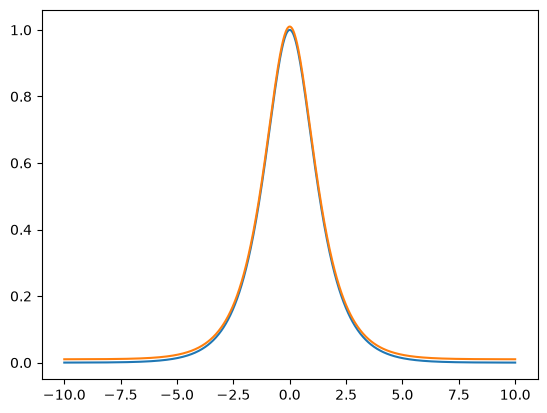

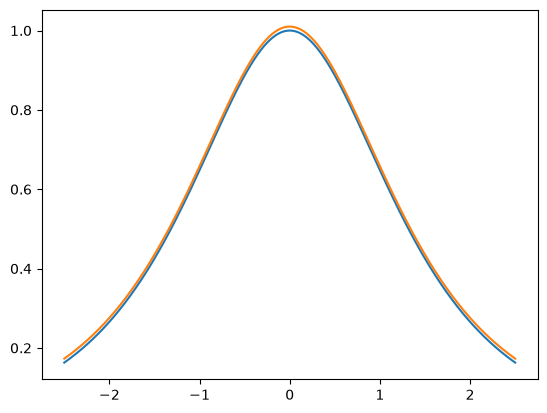

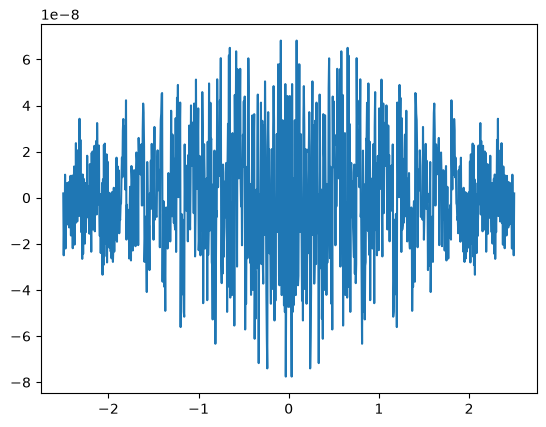

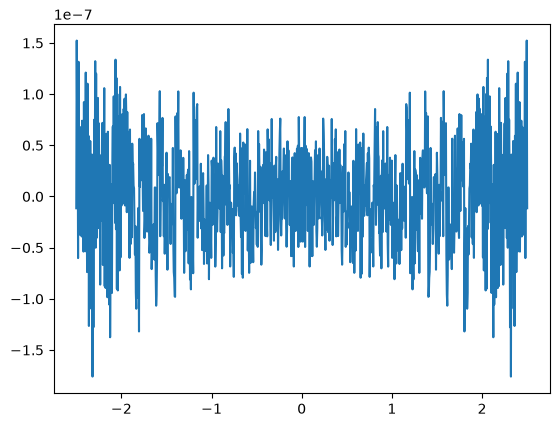

In [507]:
import numpy as np

xs = np.linspace(-10, 10, 1000)
ys = 1./np.cosh(xs)
zs = np.sin(2*np.atan(np.exp(xs))) + 0.01

plt.plot(xs, ys)
plt.plot(xs, zs)
plt.show()


xs = np.linspace(-2.5, 2.5, 1000)
ys = 1./np.cosh(xs)
zs = np.sin(2*np.atan(np.exp(xs))) + 0.01

plt.plot(xs, ys)
plt.plot(xs, zs)
plt.show()

fs = np.float32(1)/np.cosh(np.float32(xs))
plt.plot(xs, ys-fs)
plt.show()
plt.plot(xs, (fs-ys)/ys)
plt.show()


In [508]:
def et(eta) :
    return 1./cosh(eta)

xmax = mpf(1.2)

polyS, err = chebyfit(et, [-xmax, xmax], 6, error=True)
nprint(poly,12)
nprint(err,12)
print(polyval(poly,0))
nprint(polyval(poly,0.5))
nprint(polyval(poly,1))

def et2(eta) :
    return 1./cosh(sqrt(abs(eta)))


poly2, err2 = chebyfit(et2, [0, xmax*xmax], 8, error=True)
nprint(poly2,12)
nprint(err2,12)
print(polyval(poly2,0)+1)
print(polyval(poly2,0.25)+1)
nprint(polyval(poly2,1)+1)

print()

t = taylor(et, 0, 10)
nprint(t[::-1],12)
t0 = 0.5*xmax
t = taylor(et, t0, 10)
nprint(t[::-1],12)
poly, err = chebyfit(et, [0, xmax], 9, error=True)
nprint(poly,12)
nprint(poly[::-1],12)
nprint(err,12)
p, q = pade(t, 4, 4)
nprint(p)
nprint(q)
nprint(polyval(poly,0))
nprint(polyval(poly,1))
nprint(polyval(t[::-1],0-t0))
nprint(polyval(t[::-1],1-t0))
nprint(polyval(p[::-1],0-t0)/polyval(q[::-1],0-t0))
nprint(polyval(p[::-1],1-t0)/polyval(q[::-1],1-t0))

[-0.0150543655971, 0.0821370891714, -0.150307883454, 0.0295750777896, 0.200707822535, 0.00106750423055, -0.500073072319, 2.06961523705e-6, 0.999999986449]
0.00381170898664
0.999999986448588
0.886819
0.648054
[-0.000327227298688, 0.00269222779929, -0.0110532382297, 0.0326452639459, -0.0841429332445, 0.208233627049, -0.49999331836, 0.999999925173]
7.32013016614e-8
1.99999992517273
1.88681882763539
1.64805

[-0.0139222332451, 0.0, 0.0343501984127, 0.0, -0.0847222222222, 0.0, 0.208333333333, 0.0, -0.5, 0.0, 1.0]
[0.00423476657138, 0.00537569678172, -0.0184244605331, 0.00690375070967, 0.0438215171158, -0.0719805093038, -0.0379360686888, 0.246860273598, -0.178476567116, -0.453028531528, 0.843550687622]
[-0.0150543655971, 0.0821370891714, -0.150307883454, 0.0295750777896, 0.200707822535, 0.00106750423055, -0.500073072319, 2.06961523705e-6, 0.999999986449]
[0.999999986449, 2.06961523705e-6, -0.500073072319, 0.00106750423055, 0.200707822535, 0.0295750777896, -0.150307883454, 0.0821370891714, -0

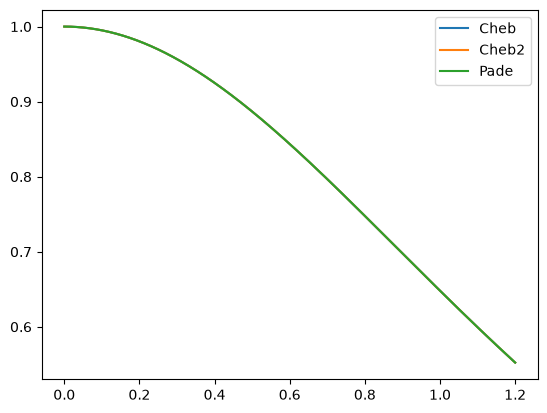

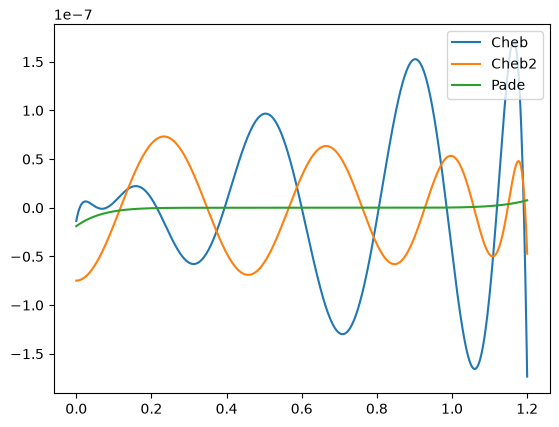

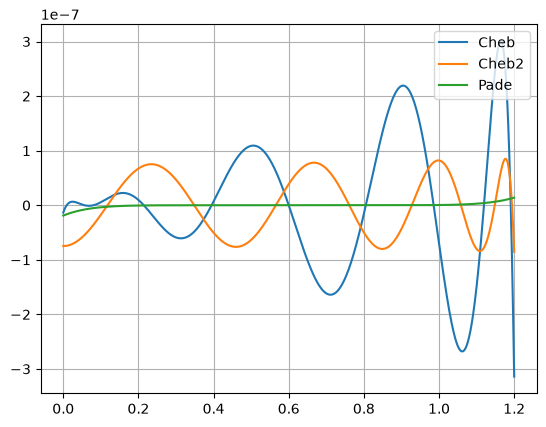

In [509]:
xs = np.linspace(0, xmax, 1000)
ys = np.fromiter((polyval(poly, xs[n]) for n in range(0,1000)),dtype=np.float64)
zs = np.fromiter((polyval(poly2, xs[n]*xs[n]) for n in range(0,1000)),dtype=np.float64)
#zs = np.fromiter((polyval(t[::-1], xs[n]-t0) for n in range(0,1000)),dtype=np.float64)
ps = np.fromiter((polyval(p[::-1],xs[n]-t0)/polyval(q[::-1], xs[n]-t0) for n in range(0,1000)),dtype=np.float64)

plt.plot(xs, ys,label='Cheb')
plt.plot(xs, zs,label='Cheb2')
plt.plot(xs, ps,label='Pade')
plt.legend(loc='upper right')
plt.show()

ys = np.fromiter(( polyval(poly, xs[n])-et(xs[n]) for n in range(0,1000)),dtype=np.float64)
zs = np.fromiter(( polyval(poly2, xs[n]*xs[n])-et(xs[n]) for n in range(0,1000)),dtype=np.float64)
#zs = np.fromiter(( polyval(t[::-1], xs[n]-t0)-et(xs[n]) for n in range(0,1000)),dtype=np.float64)
ps = np.fromiter(( polyval(p[::-1],xs[n]-t0)/polyval(q[::-1], xs[n]-t0)-et(xs[n]) for n in range(0,1000)),dtype=np.float64)

plt.plot(xs, ys,label='Cheb')
plt.plot(xs, zs,label='Cheb2')
plt.plot(xs, ps,label='Pade')
plt.legend(loc='upper right')
plt.show()

ys = np.fromiter(( ((polyval(poly, xs[n])-et(xs[n]))/et(xs[n]) ) for n in range(0,1000)),dtype=np.float64)
zs = np.fromiter(( ((polyval(poly2, xs[n]*xs[n])-et(xs[n]))/et(xs[n]) ) for n in range(0,1000)),dtype=np.float64)
#zs = np.fromiter(( ((polyval(t[::-1], xs[n]-t0)-et(xs[n]))/et(xs[n]) ) for n in range(0,1000)),dtype=mp.float64)
ps = np.fromiter(( ((polyval(p[::-1],xs[n]-t0)/polyval(q[::-1], xs[n]-t0)-et(xs[n]))/et(xs[n]) ) for n in range(0,1000)),dtype=np.float64)

plt.grid(True)
# plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.plot(xs, ys,label='Cheb')
plt.plot(xs, zs,label='Cheb2')
plt.plot(xs, ps,label='Pade')
plt.legend(loc='upper right')
plt.show()

